In [ ]:
import pandas as pd

Ausgangsmodell = pd.read_csv(r'C:\Users\jrall\Desktop\Generalisierungsvergleich\Ausgangsmodell\Generalisierungsvergleich Ausgangsmodell.analysis.csv')
Parameter_Optimiertes_Modell = pd.read_csv(r'C:\Users\jrall\Desktop\Generalisierungsvergleich\First Run Opt Model\First Run Opt Model.analysis.csv')
Finales_Modell = pd.read_csv(r'C:\Users\jrall\Desktop\Generalisierungsvergleich\Seven Final Small Sigma\Seven Final Small Sigma.analysis.csv')
Selbst_gelabelte_Frames = pd.read_csv(r'C:\Users\jrall\Desktop\Generalisierungsvergleich\Gen Vergleich Selbst Gelabelt\Generalisierungsvergleich Template self labeled.000_video0030 25-01-23 18-49-44.analysis.csv')

FileNotFoundError: [Errno 2] No such file or directory: 'C:\\Users\\jrall\\Desktop\\Generalisierungsvergleich\\Ausgangsmodell\\Generalisierungsvergleich Ausgangsmodell.analysis.csv'

In [ ]:
Selbst_gelabelte_Frames

,track,frame_idx,instance.score,nose.x,nose.y,nose.score,neck.x,neck.y,neck.score,tail_base.x,tail_base.y,tail_base.score
0,NaN,139,NaN,425.442910,75.139775,NaN,425.194046,101.941301,NaN,425.582460,186.815389,NaN
1,NaN,667,NaN,564.322613,587.015418,NaN,532.135745,587.173213,NaN,458.155468,576.624332,NaN
2,NaN,1211,NaN,404.320742,237.242322,NaN,432.524109,214.031886,NaN,437.133662,143.112466,NaN
3,NaN,1536,NaN,413.628927,140.858875,NaN,441.899194,148.117706,NaN,500.118254,187.774224,NaN
4,NaN,1879,NaN,620.118201,235.583126,NaN,620.903439,262.959043,NaN,618.393603,347.427352,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
95,NaN,26209,NaN,157.461194,492.702726,NaN,178.323643,492.418276,NaN,242.581633,527.782446,NaN
96,NaN,26538,NaN,386.220183,373.936085,NaN,353.838297,366.157800,NaN,304.824476,359.237067,NaN
97,NaN,26828,NaN,NaN,NaN,NaN,705.795651,597.281086,NaN,748.776858,538.840801,NaN
98,NaN,26867,NaN,716.725241,646.007713,NaN,717.374517,608.313077,NaN,732.532423,555.252999,NaN


Herausfinden wie viele NaN´s pro Spalte übrig geblieben sind

In [ ]:
#Herausfinden wie viele NaN´s pro Spalte übrig geblieben sind
print("Ausgangsmodell NaNs pro Spalte:")
print(Ausgangsmodell.isna().sum())
print("Parameter Optimiertes Modell NaNs pro Spalte:")
print(Parameter_Optimiertes_Modell.isna().sum())
print("Finales Modell NaNs pro Spalte:")
print(Finales_Modell.isna().sum())

Ausgangsmodell NaNs pro Spalte:
track              27002
frame_idx              0
instance.score         0
nose.x               754
nose.y               754
nose.score             0
neck.x               348
neck.y               348
neck.score             0
tail_base.x           61
tail_base.y           61
tail_base.score        0
dtype: int64
Parameter Optimiertes Modell NaNs pro Spalte:
track              26956
frame_idx              0
instance.score         0
nose.x               168
nose.y               168
nose.score             0
neck.x               172
neck.y               172
neck.score             0
tail_base.x            0
tail_base.y            0
tail_base.score        0
dtype: int64
Finales Modell NaNs pro Spalte:
track              26991
frame_idx              0
instance.score         0
nose.x               455
nose.y               455
nose.score             0
neck.x               117
neck.y               117
neck.score             0
tail_base.x          770
tail_base.y   

Neue Datensätze erstellen die nur die Frames enthalten die auch selbst gelabelt wurden.

In [ ]:
#Neue Datensätze erstellen die nur die Frames enthalten die auch selbst gelabelt wurden.
Ausgangsmodell_nur_Vergleichs_Frames = Ausgangsmodell[Ausgangsmodell['frame_idx'].isin(Selbst_gelabelte_Frames['frame_idx'])]
Parameter_Optimiertes_Modell_nur_Vergleichs_Frames = Parameter_Optimiertes_Modell[Parameter_Optimiertes_Modell['frame_idx'].isin(Selbst_gelabelte_Frames['frame_idx'])]
Finales_Modell_nur_Vergleichs_Frames = Finales_Modell[Finales_Modell['frame_idx'].isin(Selbst_gelabelte_Frames['frame_idx'])]

Euklidische Distanz zwischen den Modellen und selbst gelabelten Frames rausfinden für x und y Nose, Neck und Tail_base

In [ ]:
#Euklidische Distanz zwischen den Modellen und selbst gelabelten Frames rausfinden für x und y Nose und in Distanz_zu_Selbst_gelabelten_Frames einfügen
import numpy as np

Distanz_zu_Selbst_gelabelten_Frames = []
for index, row in Selbst_gelabelte_Frames.iterrows():
    frame_idx = row['frame_idx']
    x_selbst_gelabelt = row['nose.x']
    y_selbst_gelabelt = row['nose.y']
    
    #Finde die entsprechenden Zeilen in den Modellen
    zeile_ausgangsmodell = Ausgangsmodell_nur_Vergleichs_Frames[Ausgangsmodell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    zeile_parameter_optimiertes_modell = Parameter_Optimiertes_Modell_nur_Vergleichs_Frames[Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    zeile_finales_modell = Finales_Modell_nur_Vergleichs_Frames[Finales_Modell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    
    if not zeile_ausgangsmodell.empty and not zeile_parameter_optimiertes_modell.empty and not zeile_finales_modell.empty:
        x_ausgangsmodell = zeile_ausgangsmodell.iloc[0]['nose.x']
        y_ausgangsmodell = zeile_ausgangsmodell.iloc[0]['nose.y']
        x_parameter_optimiertes_modell = zeile_parameter_optimiertes_modell.iloc[0]['nose.x']
        y_parameter_optimiertes_modell = zeile_parameter_optimiertes_modell.iloc[0]['nose.y']
        x_finales_modell = zeile_finales_modell.iloc[0]['nose.x']
        y_finales_modell = zeile_finales_modell.iloc[0]['nose.y']
        
        distanz_ausgangsmodell = np.sqrt((x_selbst_gelabelt - x_ausgangsmodell) ** 2 + (y_selbst_gelabelt - y_ausgangsmodell) ** 2)
        distanz_parameter_optimiertes_modell = np.sqrt((x_selbst_gelabelt - x_parameter_optimiertes_modell) ** 2 + (y_selbst_gelabelt - y_parameter_optimiertes_modell) ** 2)
        distanz_finales_modell = np.sqrt((x_selbst_gelabelt - x_finales_modell) ** 2 + (y_selbst_gelabelt - y_finales_modell) ** 2)
        Distanz_zu_Selbst_gelabelten_Frames.append({
            'frame_idx': frame_idx,
            'distanz_ausgangsmodell': distanz_ausgangsmodell,
            'distanz_parameter_optimiertes_modell': distanz_parameter_optimiertes_modell,
            'distanz_finales_modell': distanz_finales_modell
        })

Distanz_zu_Selbst_gelabelten_Frames_df = pd.DataFrame(Distanz_zu_Selbst_gelabelten_Frames)
Distanz_zu_Selbst_gelabelten_Frames_df

,frame_idx,distanz_ausgangsmodell,distanz_parameter_optimiertes_modell,distanz_finales_modell
0,139.0,4.149027,40.727474,2.342375
1,667.0,11.211326,36.453777,10.499475
2,1211.0,10.087340,25.310094,8.102646
3,1536.0,7.199605,25.564680,0.810577
4,1879.0,10.632681,23.848119,7.490121
...,...,...,...,...
94,26209.0,35.659347,39.708871,39.428116
95,26538.0,15.900173,52.122628,0.810973
96,26828.0,NaN,NaN,NaN
97,26867.0,7.276944,26.844652,4.633419


In [ ]:
#Euklidische Distanz zwischen den Modellen und selbst gelabelten Frames rausfinden für x und y Nose und in Nase Distanz_zu_Selbst_gelabelten_Frames einfügen
import numpy as np

Nase_Distanz_zu_Selbst_gelabelten_Frames = []
for index, row in Selbst_gelabelte_Frames.iterrows():
    frame_idx = row['frame_idx']
    x_selbst_gelabelt = row['nose.x']
    y_selbst_gelabelt = row['nose.y']
    
    #Finde die entsprechenden Zeilen in den Modellen
    Nase_zeile_ausgangsmodell = Ausgangsmodell_nur_Vergleichs_Frames[Ausgangsmodell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    Nase_zeile_parameter_optimiertes_modell = Parameter_Optimiertes_Modell_nur_Vergleichs_Frames[Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    Nase_zeile_finales_modell = Finales_Modell_nur_Vergleichs_Frames[Finales_Modell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    
    if not Nase_zeile_ausgangsmodell.empty and not Nase_zeile_parameter_optimiertes_modell.empty and not Nase_zeile_finales_modell.empty:
        x_ausgangsmodell = Nase_zeile_ausgangsmodell.iloc[0]['nose.x']
        y_ausgangsmodell = Nase_zeile_ausgangsmodell.iloc[0]['nose.y']
        x_parameter_optimiertes_modell = Nase_zeile_parameter_optimiertes_modell.iloc[0]['nose.x']
        y_parameter_optimiertes_modell = Nase_zeile_parameter_optimiertes_modell.iloc[0]['nose.y']
        x_finales_modell = Nase_zeile_finales_modell.iloc[0]['nose.x']
        y_finales_modell = Nase_zeile_finales_modell.iloc[0]['nose.y']
        
        Nase_distanz_ausgangsmodell = np.sqrt((x_selbst_gelabelt - x_ausgangsmodell) ** 2 + (y_selbst_gelabelt - y_ausgangsmodell) ** 2)
        Nase_distanz_parameter_optimiertes_modell = np.sqrt((x_selbst_gelabelt - x_parameter_optimiertes_modell) ** 2 + (y_selbst_gelabelt - y_parameter_optimiertes_modell) ** 2)
        Nase_distanz_finales_modell = np.sqrt((x_selbst_gelabelt - x_finales_modell) ** 2 + (y_selbst_gelabelt - y_finales_modell) ** 2)
        Nase_Distanz_zu_Selbst_gelabelten_Frames.append({
            'frame_idx': frame_idx,
            'Nase_distanz_ausgangsmodell': Nase_distanz_ausgangsmodell,
            'Nase_distanz_parameter_optimiertes_modell': Nase_distanz_parameter_optimiertes_modell,
            'Nase_distanz_finales_modell': Nase_distanz_finales_modell
        })

Distanz_zu_Selbst_gelabelten_Frames_Nase_df = pd.DataFrame(Nase_Distanz_zu_Selbst_gelabelten_Frames)

#Euklidische Distanz für neck x und neck y zwischen den Modellen und selbst gelabelten Frames rausfinden und in neck Distanz_zu_Selbst_gelabelten_Frames einfügen

Neck_Distanz_zu_Selbst_gelabelten_Frames = []
for index, row in Selbst_gelabelte_Frames.iterrows():
    frame_idx = row['frame_idx']
    x_selbst_gelabelt = row['neck.x']
    y_selbst_gelabelt = row['neck.y']
    
    #Finde die entsprechenden Zeilen in den Modellen
    Neck_zeile_ausgangsmodell = Ausgangsmodell_nur_Vergleichs_Frames[Ausgangsmodell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    Neck_zeile_parameter_optimiertes_modell = Parameter_Optimiertes_Modell_nur_Vergleichs_Frames[Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    Neck_zeile_finales_modell = Finales_Modell_nur_Vergleichs_Frames[Finales_Modell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    
    if not Neck_zeile_ausgangsmodell.empty and not Neck_zeile_parameter_optimiertes_modell.empty and not Neck_zeile_finales_modell.empty:
        x_ausgangsmodell = Neck_zeile_ausgangsmodell.iloc[0]['neck.x']
        y_ausgangsmodell = Neck_zeile_ausgangsmodell.iloc[0]['neck.y']
        x_parameter_optimiertes_modell = Neck_zeile_parameter_optimiertes_modell.iloc[0]['neck.x']
        y_parameter_optimiertes_modell = Neck_zeile_parameter_optimiertes_modell.iloc[0]['neck.y']
        x_finales_modell = Neck_zeile_finales_modell.iloc[0]['neck.x']
        y_finales_modell = Neck_zeile_finales_modell.iloc[0]['neck.y']
        
        Neck_distanz_ausgangsmodell = np.sqrt((x_selbst_gelabelt - x_ausgangsmodell) ** 2 + (y_selbst_gelabelt - y_ausgangsmodell) ** 2)
        Neck_distanz_parameter_optimiertes_modell = np.sqrt((x_selbst_gelabelt - x_parameter_optimiertes_modell) ** 2 + (y_selbst_gelabelt - y_parameter_optimiertes_modell) ** 2)
        Neck_distanz_finales_modell = np.sqrt((x_selbst_gelabelt - x_finales_modell) ** 2 + (y_selbst_gelabelt - y_finales_modell) ** 2)
        Neck_Distanz_zu_Selbst_gelabelten_Frames.append({
            'frame_idx': frame_idx,
            'Neck_distanz_ausgangsmodell': Neck_distanz_ausgangsmodell,
            'Neck_distanz_parameter_optimiertes_modell': Neck_distanz_parameter_optimiertes_modell,
            'Neck_distanz_finales_modell': Neck_distanz_finales_modell
        })
Distanz_zu_Selbst_gelabelten_Frames_Neck_df = pd.DataFrame(Neck_Distanz_zu_Selbst_gelabelten_Frames)

#Euklidische Distanz für tail_base x und tail_base y zwischen den Modellen und selbst gelabelten Frames rausfinden und in tail_base Distanz_zu_Selbst_gelabelten_Frames einfügen

Tail_Base_Distanz_zu_Selbst_gelabelten_Frames = []
for index, row in Selbst_gelabelte_Frames.iterrows():
    frame_idx = row['frame_idx']
    x_selbst_gelabelt = row['tail_base.x']
    y_selbst_gelabelt = row['tail_base.y']
    
    #Finde die entsprechenden Zeilen in den Modellen
    Tail_Base_zeile_ausgangsmodell = Ausgangsmodell_nur_Vergleichs_Frames[Ausgangsmodell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    Tail_Base_zeile_parameter_optimiertes_modell = Parameter_Optimiertes_Modell_nur_Vergleichs_Frames[Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    Tail_Base_zeile_finales_modell = Finales_Modell_nur_Vergleichs_Frames[Finales_Modell_nur_Vergleichs_Frames['frame_idx'] == frame_idx]
    
    if not Tail_Base_zeile_ausgangsmodell.empty and not Tail_Base_zeile_parameter_optimiertes_modell.empty and not Tail_Base_zeile_finales_modell.empty:
        x_ausgangsmodell = Tail_Base_zeile_ausgangsmodell.iloc[0]['tail_base.x']
        y_ausgangsmodell = Tail_Base_zeile_ausgangsmodell.iloc[0]['tail_base.y']
        x_parameter_optimiertes_modell = Tail_Base_zeile_parameter_optimiertes_modell.iloc[0]['tail_base.x']
        y_parameter_optimiertes_modell = Tail_Base_zeile_parameter_optimiertes_modell.iloc[0]['tail_base.y']
        x_finales_modell = Tail_Base_zeile_finales_modell.iloc[0]['tail_base.x']
        y_finales_modell = Tail_Base_zeile_finales_modell.iloc[0]['tail_base.y']
        
        Tail_Base_distanz_ausgangsmodell = np.sqrt((x_selbst_gelabelt - x_ausgangsmodell) ** 2 + (y_selbst_gelabelt - y_ausgangsmodell) ** 2)
        Tail_Base_distanz_parameter_optimiertes_modell = np.sqrt((x_selbst_gelabelt - x_parameter_optimiertes_modell) ** 2 + (y_selbst_gelabelt - y_parameter_optimiertes_modell) ** 2)
        Tail_Base_distanz_finales_modell = np.sqrt((x_selbst_gelabelt - x_finales_modell) ** 2 + (y_selbst_gelabelt - y_finales_modell) ** 2)
        Tail_Base_Distanz_zu_Selbst_gelabelten_Frames.append({
            'frame_idx': frame_idx,
            'Tail_Base_distanz_ausgangsmodell': Tail_Base_distanz_ausgangsmodell,
            'Tail_Base_distanz_parameter_optimiertes_modell': Tail_Base_distanz_parameter_optimiertes_modell,
            'Tail_Base_distanz_finales_modell': Tail_Base_distanz_finales_modell
        })
Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df = pd.DataFrame(Tail_Base_Distanz_zu_Selbst_gelabelten_Frames)


In [ ]:
#Mittelwert der Distanzen pro Modell ausrechnen
mittelwert_ausgangsmodell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_ausgangsmodell'].mean()
mittelwert_parameter_optimiertes_modell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_parameter_optimiertes_modell'].mean()
mittelwert_finales_modell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_finales_modell'].mean()
print("Mittelwert der Distanzen zum Ausgangsmodell Nase:", mittelwert_ausgangsmodell_Nase)
print("Mittelwert der Distanzen zum Parameter Optimierten Modell Nase:", mittelwert_parameter_optimiertes_modell_Nase)
print("Mittelwert der Distanzen zum Finalen Modell Nase:", mittelwert_finales_modell_Nase)
print()
#Mittelwert der Distanzen pro Modell für neck ausrechnen
mittelwert_ausgangsmodell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_ausgangsmodell'].mean()
mittelwert_parameter_optimiertes_modell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_parameter_optimiertes_modell'].mean()
mittelwert_finales_modell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_finales_modell'].mean()
print("Mittelwert der Distanzen zum Ausgangsmodell Neck:", mittelwert_ausgangsmodell_Neck)
print("Mittelwert der Distanzen zum Parameter Optimierten Modell Neck:", mittelwert_parameter_optimiertes_modell_Neck)
print("Mittelwert der Distanzen zum Finalen Modell Neck:", mittelwert_finales_modell_Neck)
print()
#Mittelwert der Distanzen pro Modell für tail_base ausrechnen
mittelwert_ausgangsmodell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_ausgangsmodell'].mean()
mittelwert_parameter_optimiertes_modell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_parameter_optimiertes_modell'].mean()
mittelwert_finales_modell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_finales_modell'].mean()
print("Mittelwert der Distanzen zum Ausgangsmodell Tail_Base:", mittelwert_ausgangsmodell_Tail_Base)
print("Mittelwert der Distanzen zum Parameter Optimierten Modell Tail_Base:", mittelwert_parameter_optimiertes_modell_Tail_Base)
print("Mittelwert der Distanzen zum Finalen Modell Tail_Base:", mittelwert_finales_modell_Tail_Base)
print()

#SEM der Distanzen pro Modell ausrechnen
sem_ausgangsmodell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_ausgangsmodell'].sem()
sem_parameter_optimiertes_modell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_parameter_optimiertes_modell'].sem()
sem_finales_modell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_finales_modell'].sem()
print("SEM der Distanzen zum Ausgangsmodell Nase:", sem_ausgangsmodell_Nase)
print("SEM der Distanzen zum Parameter Optimierten Modell Nase:", sem_parameter_optimiertes_modell_Nase)
print("SEM der Distanzen zum Finalen Modell Nase:", sem_finales_modell_Nase)
print()
sem_ausgangsmodell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_ausgangsmodell'].sem()
sem_parameter_optimiertes_modell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_parameter_optimiertes_modell'].sem()
sem_finales_modell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_finales_modell'].sem()
print("SEM der Distanzen zum Ausgangsmodell Neck:", sem_ausgangsmodell_Neck)
print("SEM der Distanzen zum Parameter Optimierten Modell Neck:", sem_parameter_optimiertes_modell_Neck)
print("SEM der Distanzen zum Finalen Modell Neck:", sem_finales_modell_Neck)
print()
sem_ausgangsmodell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_ausgangsmodell'].sem()
sem_parameter_optimiertes_modell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_parameter_optimiertes_modell'].sem()
sem_finales_modell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_finales_modell'].sem()
print("SEM der Distanzen zum Ausgangsmodell Tail_Base:", sem_ausgangsmodell_Tail_Base)
print("SEM der Distanzen zum Parameter Optimierten Modell Tail_Base:", sem_parameter_optimiertes_modell_Tail_Base)
print("SEM der Distanzen zum Finalen Modell Tail_Base:", sem_finales_modell_Tail_Base)
print()

#Maximum der Distanzen pro Modell ausrechnen
max_ausgangsmodell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_ausgangsmodell'].max()
max_parameter_optimiertes_modell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_parameter_optimiertes_modell'].max()
max_finales_modell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_finales_modell'].max()
print("Maximum der Distanzen zum Ausgangsmodell Nase:", max_ausgangsmodell_Nase)
print("Maximum der Distanzen zum Parameter Optimierten Modell Nase:", max_parameter_optimiertes_modell_Nase)
print("Maximum der Distanzen zum Finalen Modell Nase:", max_finales_modell_Nase)
print()
max_ausgangsmodell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_ausgangsmodell'].max()
max_parameter_optimiertes_modell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_parameter_optimiertes_modell'].max()
max_finales_modell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_finales_modell'].max()
print("Maximum der Distanzen zum Ausgangsmodell Neck:", max_ausgangsmodell_Neck)
print("Maximum der Distanzen zum Parameter Optimierten Modell Neck:", max_parameter_optimiertes_modell_Neck)
print("Maximum der Distanzen zum Finalen Modell Neck:", max_finales_modell_Neck)
print()
max_ausgangsmodell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_ausgangsmodell'].max()
max_parameter_optimiertes_modell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_parameter_optimiertes_modell'].max()
max_finales_modell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_finales_modell'].max()
print("Maximum der Distanzen zum Ausgangsmodell Tail_Base:", max_ausgangsmodell_Tail_Base)
print("Maximum der Distanzen zum Parameter Optimierten Modell Tail_Base:", max_parameter_optimiertes_modell_Tail_Base)
print("Maximum der Distanzen zum Finalen Modell Tail_Base:", max_finales_modell_Tail_Base)
print()
#Minimum der Distanzen pro Modell ausrechnen
min_ausgangsmodell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_ausgangsmodell'].min()
min_parameter_optimiertes_modell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_parameter_optimiertes_modell'].min()
min_finales_modell_Nase = Distanz_zu_Selbst_gelabelten_Frames_df['distanz_finales_modell'].min()
print("Minimum der Distanzen zum Ausgangsmodell Nase:", min_ausgangsmodell_Nase)
print("Minimum der Distanzen zum Parameter Optimierten Modell Nase:", min_parameter_optimiertes_modell_Nase)
print("Minimum der Distanzen zum Finalen Modell Nase:", min_finales_modell_Nase)
print()
min_ausgangsmodell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_ausgangsmodell'].min()
min_parameter_optimiertes_modell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_parameter_optimiertes_modell'].min()
min_finales_modell_Neck = Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_finales_modell'].min()
print("Minimum der Distanzen zum Ausgangsmodell Neck:", min_ausgangsmodell_Neck)
print("Minimum der Distanzen zum Parameter Optimierten Modell Neck:", min_parameter_optimiertes_modell_Neck)
print("Minimum der Distanzen zum Finalen Modell Neck:", min_finales_modell_Neck)
print()
min_ausgangsmodell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_ausgangsmodell'].min()
min_parameter_optimiertes_modell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_parameter_optimiertes_modell'].min()
min_finales_modell_Tail_Base = Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_finales_modell'].min()
print("Minimum der Distanzen zum Ausgangsmodell Tail_Base:", min_ausgangsmodell_Tail_Base)
print("Minimum der Distanzen zum Parameter Optimierten Modell Tail_Base:", min_parameter_optimiertes_modell_Tail_Base)
print("Minimum der Distanzen zum Finalen Modell Tail_Base:", min_finales_modell_Tail_Base)


Mittelwert der Distanzen zum Ausgangsmodell Nase: 11.171816122362044
Mittelwert der Distanzen zum Parameter Optimierten Modell Nase: 26.00224527933248
Mittelwert der Distanzen zum Finalen Modell Nase: 7.84204972229401

Mittelwert der Distanzen zum Ausgangsmodell Neck: 10.176152065624445
Mittelwert der Distanzen zum Parameter Optimierten Modell Neck: 13.91677302367454
Mittelwert der Distanzen zum Finalen Modell Neck: 7.943907775800743

Mittelwert der Distanzen zum Ausgangsmodell Tail_Base: 19.820879693125733
Mittelwert der Distanzen zum Parameter Optimierten Modell Tail_Base: 33.26663405455007
Mittelwert der Distanzen zum Finalen Modell Tail_Base: 4.276367483549761

SEM der Distanzen zum Ausgangsmodell Nase: 1.2518125930492425
SEM der Distanzen zum Parameter Optimierten Modell Nase: 1.5895592220740598
SEM der Distanzen zum Finalen Modell Nase: 1.2707707506422274

SEM der Distanzen zum Ausgangsmodell Neck: 0.7263882213689155
SEM der Distanzen zum Parameter Optimierten Modell Neck: 0.9162

Scatterplot um Koordinaten visuell zu vergleichen

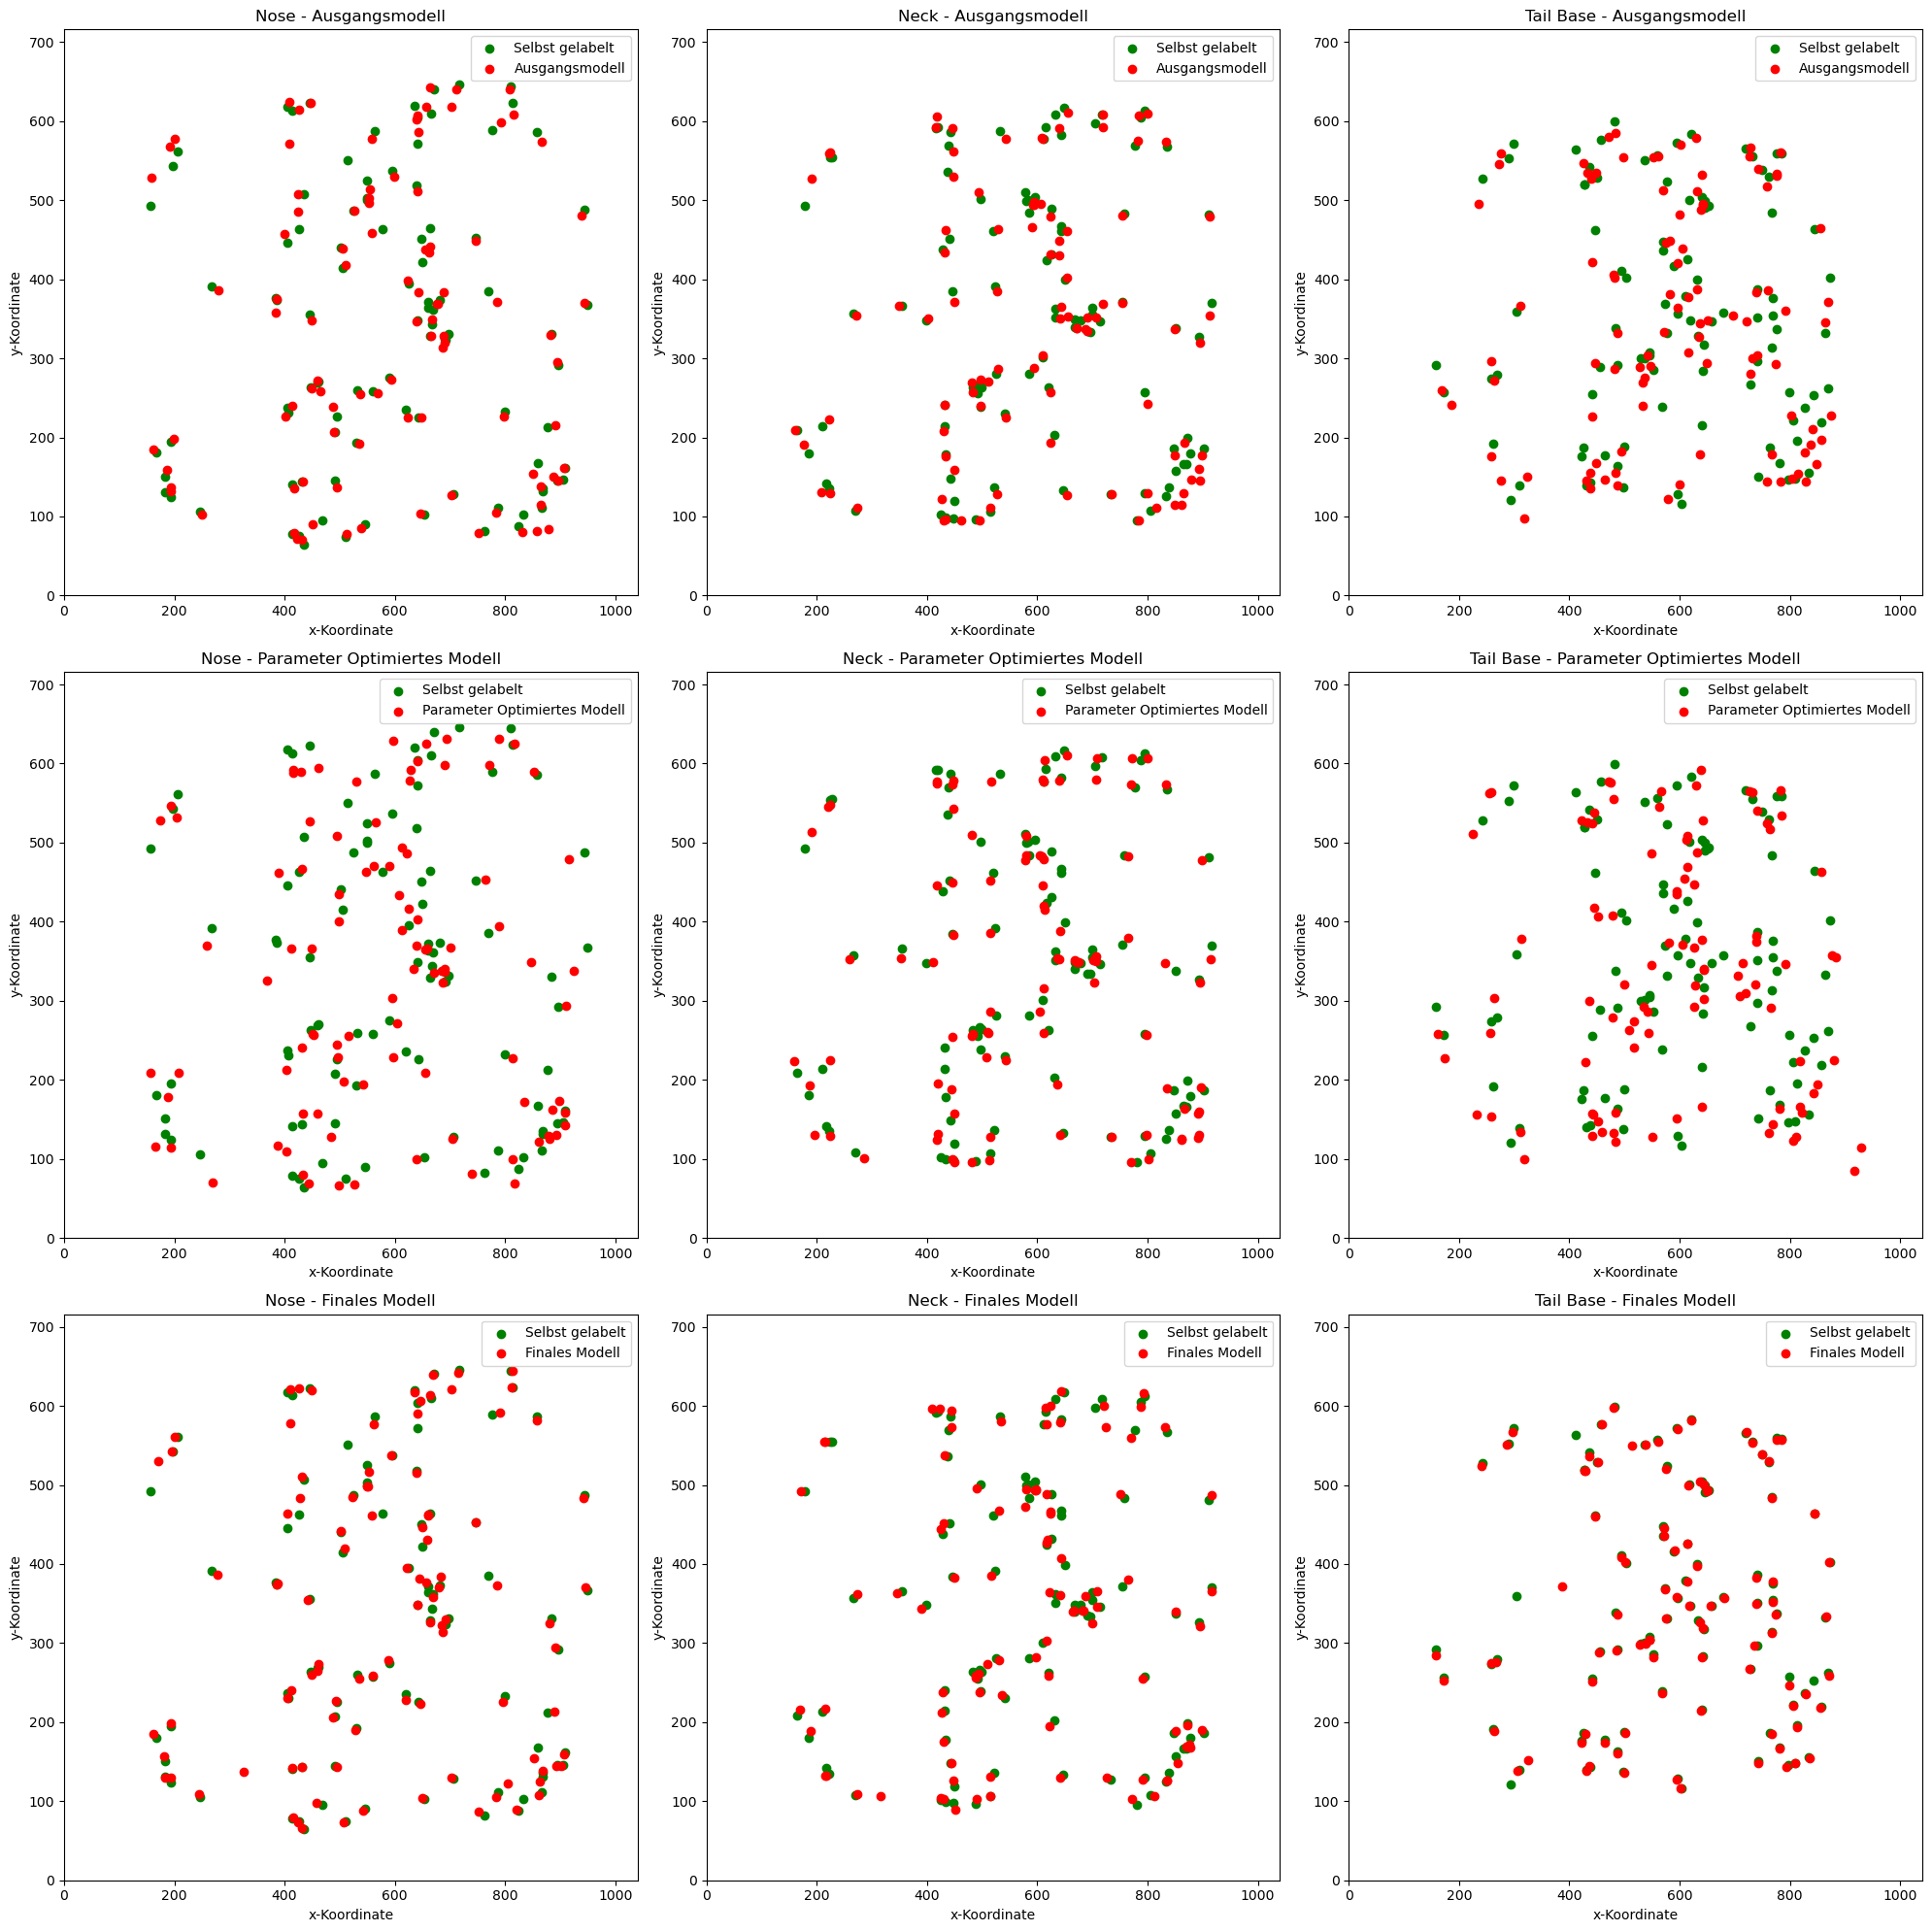

In [ ]:
#Scatterplot um Koordinaten visuell zu vergleichen für Nase, Neck und Tail Base
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 20))
plt.subplot(3, 3, 1)
plt.scatter(Selbst_gelabelte_Frames['nose.x'], Selbst_gelabelte_Frames['nose.y'], label='Selbst gelabelt', color='green')
plt.scatter(Ausgangsmodell_nur_Vergleichs_Frames['nose.x'], Ausgangsmodell_nur_Vergleichs_Frames['nose.y'], label='Ausgangsmodell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Nose - Ausgangsmodell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')

plt.subplot(3, 3, 2)
plt.scatter(Selbst_gelabelte_Frames['neck.x'], Selbst_gelabelte_Frames['neck.y'], label='Selbst gelabelt', color='green')
plt.scatter(Ausgangsmodell_nur_Vergleichs_Frames['neck.x'], Ausgangsmodell_nur_Vergleichs_Frames['neck.y'], label='Ausgangsmodell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Neck - Ausgangsmodell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')

plt.subplot(3, 3, 3)
plt.scatter(Selbst_gelabelte_Frames['tail_base.x'], Selbst_gelabelte_Frames['tail_base.y'], label='Selbst gelabelt', color='green')
plt.scatter(Ausgangsmodell_nur_Vergleichs_Frames['tail_base.x'], Ausgangsmodell_nur_Vergleichs_Frames['tail_base.y'], label='Ausgangsmodell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Tail Base - Ausgangsmodell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')

plt.subplot(3, 3, 4)
plt.scatter(Selbst_gelabelte_Frames['nose.x'], Selbst_gelabelte_Frames['nose.y'], label='Selbst gelabelt', color='green')
plt.scatter(Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['nose.x'], Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['nose.y'], label='Parameter Optimiertes Modell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Nose - Parameter Optimiertes Modell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')

plt.subplot(3, 3, 5)
plt.scatter(Selbst_gelabelte_Frames['neck.x'], Selbst_gelabelte_Frames['neck.y'], label='Selbst gelabelt', color='green')
plt.scatter(Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['neck.x'], Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['neck.y'], label='Parameter Optimiertes Modell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Neck - Parameter Optimiertes Modell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')

plt.subplot(3, 3, 6)
plt.scatter(Selbst_gelabelte_Frames['tail_base.x'], Selbst_gelabelte_Frames['tail_base.y'], label='Selbst gelabelt', color='green')
plt.scatter(Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['tail_base.x'], Parameter_Optimiertes_Modell_nur_Vergleichs_Frames['tail_base.y'], label='Parameter Optimiertes Modell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Tail Base - Parameter Optimiertes Modell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')

plt.subplot(3, 3, 7)
plt.scatter(Selbst_gelabelte_Frames['nose.x'], Selbst_gelabelte_Frames['nose.y'], label='Selbst gelabelt', color='green')
plt.scatter(Finales_Modell_nur_Vergleichs_Frames['nose.x'], Finales_Modell_nur_Vergleichs_Frames['nose.y'], label='Finales Modell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Nose - Finales Modell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')

plt.subplot(3, 3, 8)
plt.scatter(Selbst_gelabelte_Frames['neck.x'], Selbst_gelabelte_Frames['neck.y'], label='Selbst gelabelt', color='green')
plt.scatter(Finales_Modell_nur_Vergleichs_Frames['neck.x'], Finales_Modell_nur_Vergleichs_Frames['neck.y'], label='Finales Modell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Neck - Finales Modell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')

plt.subplot(3, 3, 9)
plt.scatter(Selbst_gelabelte_Frames['tail_base.x'], Selbst_gelabelte_Frames['tail_base.y'], label='Selbst gelabelt', color='green')
plt.scatter(Finales_Modell_nur_Vergleichs_Frames['tail_base.x'], Finales_Modell_nur_Vergleichs_Frames['tail_base.y'], label='Finales Modell', color='red')
plt.legend()
plt.xlim(0,1040)
plt.ylim(0,716)
plt.tight_layout()
plt.title('Tail Base - Finales Modell')
plt.ylabel('y-Koordinate')
plt.xlabel('x-Koordinate')
plt.show()

Histograme zur euklidischen Distanz erstellen um die Verteilung  zu Visualisieren über die 

In [ ]:
Distanz_zu_Selbst_gelabelten_Frames_Nase_df

,frame_idx,Nase_distanz_ausgangsmodell,Nase_distanz_parameter_optimiertes_modell,Nase_distanz_finales_modell
0,139.0,4.149027,40.727474,2.342375
1,667.0,11.211326,36.453777,10.499475
2,1211.0,10.087340,25.310094,8.102646
3,1536.0,7.199605,25.564680,0.810577
4,1879.0,10.632681,23.848119,7.490121
...,...,...,...,...
94,26209.0,35.659347,39.708871,39.428116
95,26538.0,15.900173,52.122628,0.810973
96,26828.0,NaN,NaN,NaN
97,26867.0,7.276944,26.844652,4.633419


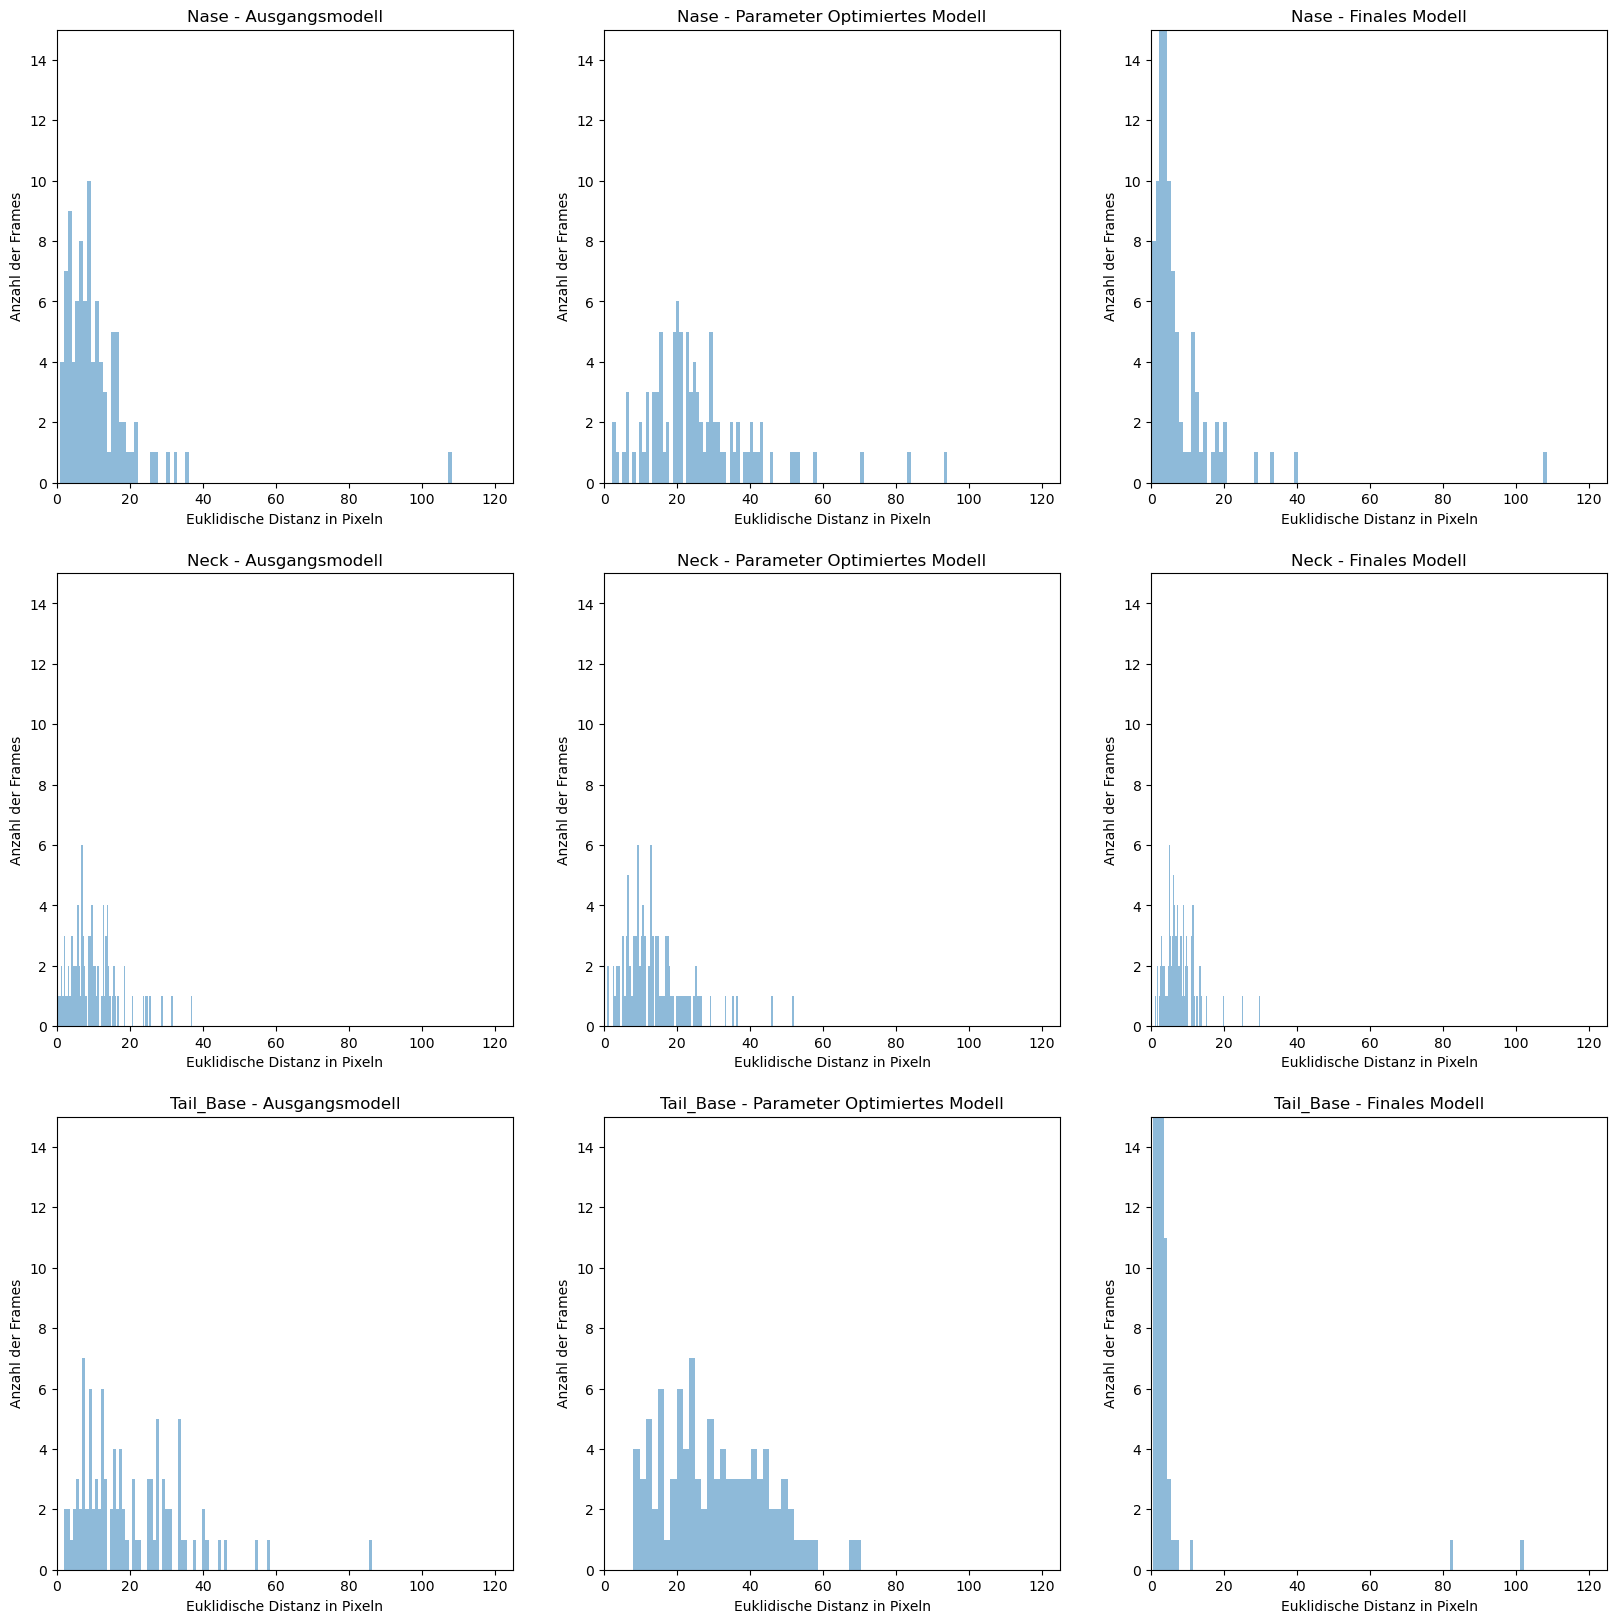

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20, 20))
plt.subplot(3, 3, 1)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Nase_df['Nase_distanz_ausgangsmodell'], bins=100, alpha=0.5, label='Ausgangsmodell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Nase - Ausgangsmodell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')

plt.subplot(3, 3, 2)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Nase_df['Nase_distanz_parameter_optimiertes_modell'], bins=100, alpha=0.5, label='Parameter Optimiertes Modell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Nase - Parameter Optimiertes Modell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')

plt.subplot(3, 3, 3)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Nase_df['Nase_distanz_finales_modell'], bins=100, alpha=0.5, label='Finales Modell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Nase - Finales Modell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')

plt.subplot(3, 3, 4)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_ausgangsmodell'], bins=100, alpha=0.5, label='Ausgangsmodell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Neck - Ausgangsmodell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')

plt.subplot(3, 3, 5)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_parameter_optimiertes_modell'], bins=100, alpha=0.5, label='Parameter Optimiertes Modell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Neck - Parameter Optimiertes Modell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')

plt.subplot(3, 3, 6)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_finales_modell'], bins=100, alpha=0.5, label='Finales Modell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Neck - Finales Modell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')

plt.subplot(3, 3, 7)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_ausgangsmodell'], bins=100, alpha=0.5, label='Ausgangsmodell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Tail_Base - Ausgangsmodell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')

plt.subplot(3, 3, 8)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_parameter_optimiertes_modell'], bins=100, alpha=0.5, label='Parameter Optimiertes Modell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Tail_Base - Parameter Optimiertes Modell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')

plt.subplot(3, 3, 9)
plt.hist(Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_finales_modell'], bins=100, alpha=0.5, label='Finales Modell')
plt.xlim(0, 125)
plt.ylim(0, 15)
plt.title('Tail_Base - Finales Modell')
plt.ylabel('Anzahl der Frames')
plt.xlabel('Euklidische Distanz in Pixeln')
plt.show()

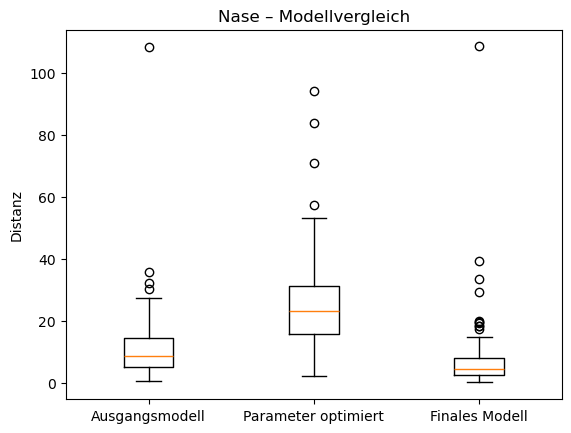

In [ ]:
fig, ax = plt.subplots()

data = [
    Distanz_zu_Selbst_gelabelten_Frames_Nase_df['Nase_distanz_ausgangsmodell'].dropna(),
    Distanz_zu_Selbst_gelabelten_Frames_Nase_df['Nase_distanz_parameter_optimiertes_modell'].dropna(),
    Distanz_zu_Selbst_gelabelten_Frames_Nase_df['Nase_distanz_finales_modell'].dropna()
]

ax.boxplot(
    data,
    tick_labels=['Ausgangsmodell', 'Parameter optimiert', 'Finales Modell']
)

ax.set_ylabel("Distanz")
ax.set_title("Nase – Modellvergleich")

plt.show()


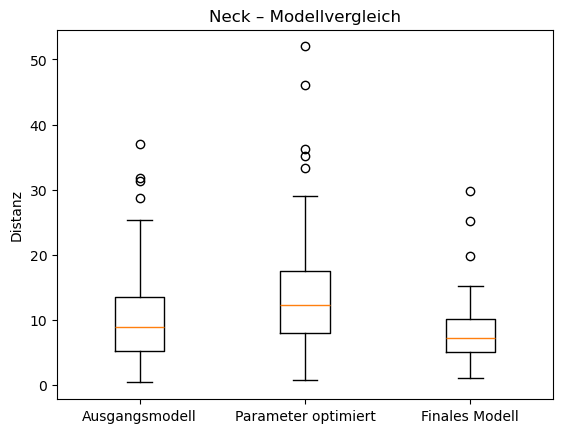

In [ ]:
fig, ax = plt.subplots()

data = [
    Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_ausgangsmodell'].dropna(),
    Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_parameter_optimiertes_modell'].dropna(),
    Distanz_zu_Selbst_gelabelten_Frames_Neck_df['Neck_distanz_finales_modell'].dropna()
]

ax.boxplot(
    data,
    tick_labels=['Ausgangsmodell', 'Parameter optimiert', 'Finales Modell']
)

ax.set_ylabel("Distanz")
ax.set_title("Neck – Modellvergleich")

plt.show()

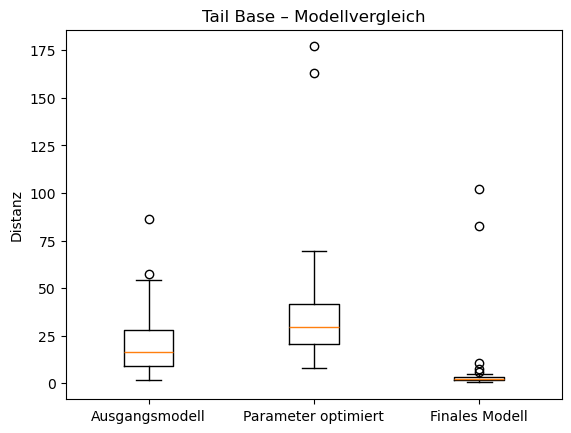

In [ ]:
fig, ax = plt.subplots()

data = [
    Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_ausgangsmodell'].dropna(),
    Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_parameter_optimiertes_modell'].dropna(),
    Distanz_zu_Selbst_gelabelten_Frames_Tail_Base_df['Tail_Base_distanz_finales_modell'].dropna()
]

ax.boxplot(
    data,
    tick_labels=['Ausgangsmodell', 'Parameter optimiert', 'Finales Modell']
)

ax.set_ylabel("Distanz")
ax.set_title("Tail Base – Modellvergleich")

plt.show()

In [ ]:
!pip list